# Prédiction de WMI — pipeline propre

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, RepeatedKFold, KFold, cross_validate,
    learning_curve, GridSearchCV,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

pd.set_option("display.precision", 3)

## Chargement des données

In [3]:
filepath = r"C:\Users\melan\DESU_DATA_2026\ProjetNR\data2026.xlsx"
raw_df = pd.read_excel(filepath, engine="openpyxl", sheet_name='Total2', header=0,
                       na_values=['na', 'NaN', 'NA', 'N/A', 'n/a', 'nan'])
raw_df.head()

,Patient,Hipp,P300,P600,LNC,N400,LRC,IQ,VCI,PRI,WMI,SPI,VBL,VSL,VBD,VSD,OB,ON
0,2 D,NI,-68.8,82.60,-54.1,NaN,NaN,96.0,98.0,100.0,91.0,94.0,105.0,123.0,101.0,115.0,98%,80/77
1,3 G,NI,-44.7,80.00,-46.9,0.0,4.69,122.0,116.0,124.0,120.0,105.0,105.0,103.0,104.0,103.0,NaN,NaN
2,4 D,NI,-108.1,96.40,-26.6,-50.7,-0.55,86.0,82.0,94.0,86.0,100.0,79.0,91.0,69.0,88.0,98%,62/70
3,6 D,NI,-35.3,0.00,0.0,23.7,-0.30,67.0,71.0,86.0,68.0,64.0,102.0,85.0,104.0,85.0,88%,53/69
4,6 G,NI,-38.7,42.14,0.0,NaN,NaN,67.0,71.0,86.0,68.0,64.0,102.0,85.0,104.0,85.0,88%,53/69


## Split train / test — AVANT tout pretraitement

Règle d'or : **aucune information du test (y compris la cible) ne doit jamais entrer dans
le fit d'un encodeur, d'un imputer, d'un scaler ou d'un modèle.**
On sépare donc X (prédicteurs uniquement, sans la cible) et y (la cible), puis on fait le split.

In [4]:
TARGET_COLUMN = "WMI"
PREDICTOR_COLUMNS = ["P300", "P600", "LNC", "N400", "LRC", "OB", "ON", "Hipp"]

X = raw_df[PREDICTOR_COLUMNS].copy()
y = raw_df[TARGET_COLUMN].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

print(f"Cible : {TARGET_COLUMN}")
print(f"Train : {X_train.shape[0]} patients | Test : {X_test.shape[0]} patients")

Cible : WMI
Train : 43 patients | Test : 22 patients


## Encodage de `Hipp`

L'encodeur est **fit uniquement sur `X_train`**, puis simplement appliqué (`transform`) sur
`X_test` avec `handle_unknown="ignore"` au cas où une catégorie rare n'apparaîtrait que dans le test.

In [5]:
def encode_hipp(df, encoder, fit=False):
    df = df.copy()
    if fit:
        encoded = encoder.fit_transform(df[["Hipp"]])
    else:
        encoded = encoder.transform(df[["Hipp"]])
    hipp_columns = encoder.get_feature_names_out(["Hipp"])
    encoded_df = pd.DataFrame(encoded, columns=hipp_columns, index=df.index)
    return pd.concat([df.drop(columns=["Hipp"]), encoded_df], axis=1)

hipp_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_train = encode_hipp(X_train, hipp_encoder, fit=True)
X_test = encode_hipp(X_test, hipp_encoder, fit=False)

X_train.head()

,P300,P600,LNC,N400,LRC,OB,ON,Hipp_NI,Hipp_ZE,Hipp_ZP
4,-38.7,42.14,0.0,NaN,NaN,88%,53/69,1.0,0.0,0.0
48,0.0,157.90,-39.7,-31.9,0.0,NaN,NaN,0.0,1.0,0.0
36,-103.5,184.60,-62.4,-26.7,0.0,NaN,NaN,0.0,1.0,0.0
19,-293.4,50.60,-39.3,-27.8,6.4,1,NaN,0.0,0.0,1.0
55,0.0,0.00,-66.5,-20.2,0.0,1,57/78,0.0,1.0,0.0


## Nettoyage des données (colonnes trop incomplètes)

Le seuil de suppression est calculé **uniquement sur `X_train`**, puis la même liste de colonnes
est retirée de `X_test` — sans jamais regarder les valeurs du test pour décider quoi supprimer.

In [6]:
percent_missing = X_train.isnull().sum() * 100 / len(X_train)
percent_missing.sort_values(ascending=False, inplace=True)
percent_missing

ON         65.116
OB         62.791
LRC        30.233
N400       30.233
P600        4.651
P300        4.651
LNC         4.651
Hipp_NI     0.000
Hipp_ZE     0.000
Hipp_ZP     0.000
dtype: float64

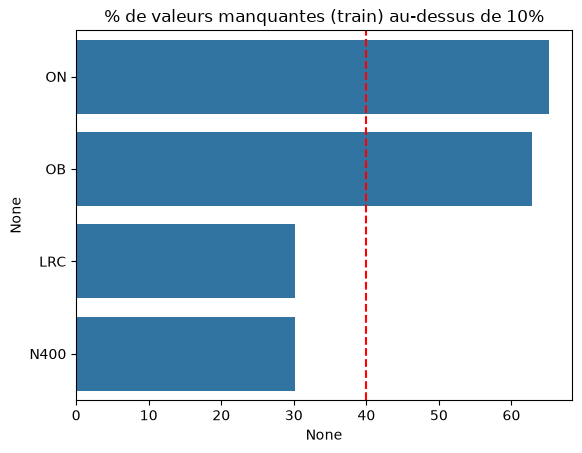

In [7]:
threshold_view = 10
filtered = percent_missing[percent_missing.values > threshold_view]

threshold = 40
if len(filtered) > 0:
    ax = sns.barplot(x=filtered, y=filtered.index, orient='h')
    ax.set_title(f"% de valeurs manquantes (train) au-dessus de {threshold_view}%")
    ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")
else:
    print("Aucune colonne au-dessus du seuil d'affichage.")

In [8]:
columns_to_drop = percent_missing[percent_missing.values > threshold].index

X_train = X_train.drop(columns=columns_to_drop, errors="ignore")
X_test = X_test.drop(columns=columns_to_drop, errors="ignore")

print(f"Colonnes supprimées (> {threshold}% manquant sur le train) : {list(columns_to_drop)}")
X_train.shape, X_test.shape

Colonnes supprimées (> 40% manquant sur le train) : ['ON', 'OB']


((43, 8), (22, 8))

## Imputation des valeurs manquantes

**Point critique :** le `KNNImputer` est fit **uniquement sur les prédicteurs de `X_train`**
(jamais sur la cible). Le même imputer, déjà entraîné, est ensuite juste appliqué (`transform`,
pas `fit_transform`) sur `X_test`.

In [9]:
numeric_columns = X_train.select_dtypes(include=["float", "int"]).columns

imputer = KNNImputer(missing_values=np.nan)
imputer.fit(X_train[numeric_columns])

X_train_imputed = X_train.copy()
X_train_imputed[numeric_columns] = imputer.transform(X_train[numeric_columns])

X_test_imputed = X_test.copy()
X_test_imputed[numeric_columns] = imputer.transform(X_test[numeric_columns])

X_train_imputed.shape, X_test_imputed.shape

((43, 8), (22, 8))

### Retirer les lignes où la cible (`WMI`) est manquante

On n'impute jamais la variable à prédire : impossible d'entraîner ou d'évaluer sur une ligne
dont on ne connaît pas la vraie réponse. On filtre donc train et test séparément.

In [10]:
train_mask = y_train.notna()
test_mask = y_test.notna()

print(f"Lignes retirées (train, {TARGET_COLUMN} manquant) : {(~train_mask).sum()}")
print(f"Lignes retirées (test, {TARGET_COLUMN} manquant)  : {(~test_mask).sum()}")

X_train_imputed = X_train_imputed.loc[train_mask]
y_train = y_train.loc[train_mask]

X_test_imputed = X_test_imputed.loc[test_mask]
y_test = y_test.loc[test_mask]

print(f"Train final : {X_train_imputed.shape[0]} patients | Test final : {X_test_imputed.shape[0]} patients")

Lignes retirées (train, WMI manquant) : 2
Lignes retirées (test, WMI manquant)  : 0
Train final : 41 patients | Test final : 22 patients


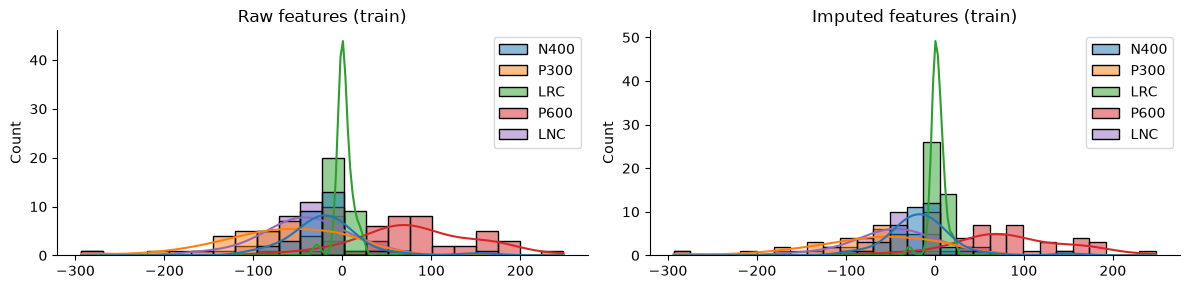

In [11]:
def compare_dist(features):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    sns.histplot(X_train.loc[:, features], kde=True, ax=axes[0])
    axes[0].set_title("Raw features (train)")
    sns.histplot(X_train_imputed.loc[:, features], kde=True, ax=axes[1])
    axes[1].set_title("Imputed features (train)")
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

compare_dist(["N400", "P300", "LRC", "P600", "LNC"])

## Comparaison des modèles — validation croisée strictement sur le TRAIN

Le `StandardScaler` reste dans la `Pipeline` pour être re-fit à chaque pli de la CV.
Le test (`X_test_imputed`, `y_test`) reste intouché jusqu'à l'évaluation finale.

In [12]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1, max_iter=10000),
    "Elastic Net": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
    "PLS Regression": PLSRegression(n_components=2),
    "SVR (default)": SVR(kernel="rbf", C=1, epsilon=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)

def evaluate_model(name, model, X, y, cv):
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model),
    ])
    scores = cross_validate(
        pipeline, X, y, cv=cv,
        scoring={"R2": "r2", "RMSE": "neg_root_mean_squared_error", "MAE": "neg_mean_absolute_error"},
        return_train_score=False,
    )
    return {
        "Model": name,
        "R2_mean": np.mean(scores["test_R2"]),
        "R2_std": np.std(scores["test_R2"]),
        "RMSE_mean": -np.mean(scores["test_RMSE"]),
        "MAE_mean": -np.mean(scores["test_MAE"]),
    }

results = [evaluate_model(name, model, X_train_imputed, np.ravel(y_train), cv)
           for name, model in models.items()]

results_df = pd.DataFrame(results).sort_values("R2_mean", ascending=False).reset_index(drop=True)
results_df

,Model,R2_mean,R2_std,RMSE_mean,MAE_mean
0,SVR (default),-0.167,0.196,16.948,13.813
1,Random Forest,-0.504,0.469,18.803,15.370
2,Elastic Net,-0.515,0.537,18.991,15.996
3,Ridge,-0.543,0.570,19.134,16.175
4,Lasso,-0.569,0.593,19.277,16.305
5,Linear Regression,-0.586,0.615,19.358,16.435
6,PLS Regression,-0.614,0.642,19.482,16.269
7,Gradient Boosting,-0.812,0.966,20.029,16.185


## Optimisation des hyperparamètres du SVR (GridSearchCV)

Le SVR par défaut performait mal — avant de l'écarter, on cherche ses meilleurs hyperparamètres
sur une grille raisonnable, avec une CV plus légère (adaptée à un petit échantillon).

In [13]:
param_grid = {
    "model__C": [0.1, 1, 10],
    "model__epsilon": [0.1, 0.5],
    "model__gamma": ["scale", "auto"],
    "model__kernel": ["rbf", "linear"],
}

svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR()),
])

cv_grid = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    svr_pipeline,
    param_grid=param_grid,
    scoring="r2",
    cv=cv_grid,
    n_jobs=1,   # séquentiel : évite les blocages multiprocessing sous Windows/VS Code
)

grid_search.fit(X_train_imputed, np.ravel(y_train))

print("Meilleurs hyperparamètres SVR :", grid_search.best_params_)
print(f"Meilleur R² moyen (CV, train) : {grid_search.best_score_:.3f}")

best_svr = grid_search.best_estimator_.named_steps["model"]
models["SVR (tuned)"] = best_svr

Meilleurs hyperparamètres SVR : {'model__C': 1, 'model__epsilon': 0.5, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Meilleur R² moyen (CV, train) : -0.048


### Tableau de résultats mis à jour (avec le SVR réglé)

In [14]:
svr_tuned_result = evaluate_model("SVR (tuned)", best_svr, X_train_imputed, np.ravel(y_train), cv)

results_df = pd.concat(
    [results_df[results_df["Model"] != "SVR (tuned)"], pd.DataFrame([svr_tuned_result])],
    ignore_index=True,
).sort_values("R2_mean", ascending=False).reset_index(drop=True)

results_df

,Model,R2_mean,R2_std,RMSE_mean,MAE_mean
0,SVR (default),-0.167,0.196,16.948,13.813
1,SVR (tuned),-0.168,0.198,16.952,13.801
2,Random Forest,-0.504,0.469,18.803,15.370
3,Elastic Net,-0.515,0.537,18.991,15.996
4,Ridge,-0.543,0.570,19.134,16.175
5,Lasso,-0.569,0.593,19.277,16.305
6,Linear Regression,-0.586,0.615,19.358,16.435
7,PLS Regression,-0.614,0.642,19.482,16.269
8,Gradient Boosting,-0.812,0.966,20.029,16.185


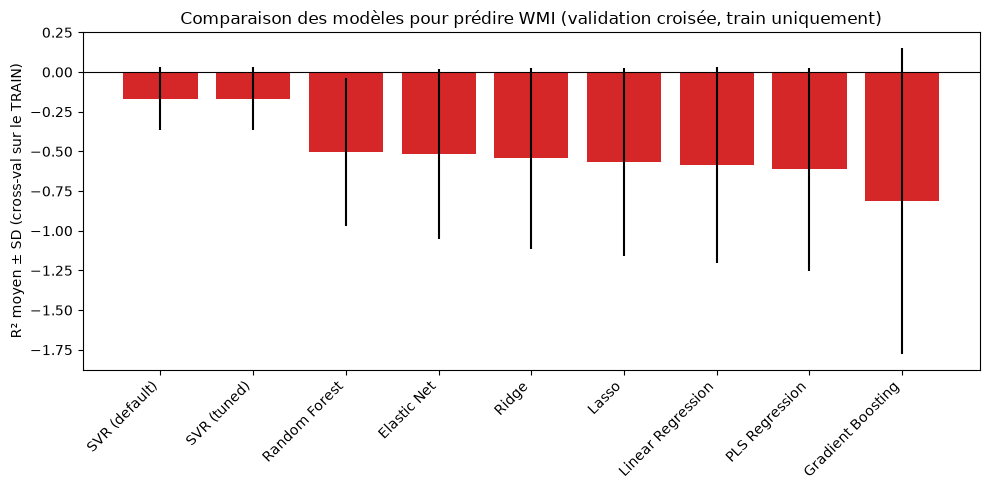

In [15]:
plt.figure(figsize=(10, 5))
colors = ["#2ca02c" if r2 >= 0 else "#d62728" for r2 in results_df["R2_mean"]]
plt.bar(results_df["Model"], results_df["R2_mean"], yerr=results_df["R2_std"], color=colors)
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=45, ha="right")
plt.ylabel("R² moyen ± SD (cross-val sur le TRAIN)")
plt.title(f"Comparaison des modèles pour prédire {TARGET_COLUMN} (validation croisée, train uniquement)")
plt.tight_layout()
plt.show()

## Sélection du meilleur modèle et évaluation UNIQUE sur le test

Le modèle est choisi selon le meilleur `R2_mean` en CV **sur le train**. On l'entraîne
ensuite une seule fois sur tout le train, puis on l'évalue **une seule fois** sur le test —
la seule métrique qui compte pour juger de la performance réelle hors échantillon.

In [16]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", best_model),
])

final_pipeline.fit(X_train_imputed, np.ravel(y_train))
y_pred_test = final_pipeline.predict(X_test_imputed)

test_r2 = r2_score(y_test, y_pred_test)
test_rmse = root_mean_squared_error(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)

summary_test = pd.DataFrame([{
    "Modèle retenu": best_model_name,
    "R² (test)": round(test_r2, 3),
    "RMSE (test)": round(test_rmse, 3),
    "MAE (test)": round(test_mae, 3),
    "R² CV (train)": round(results_df.iloc[0]["R2_mean"], 3),
}])
summary_test

,Modèle retenu,R² (test),RMSE (test),MAE (test),R² CV (train)
0,SVR (default),0.014,14.7,11.627,-0.167


### Visualisation : valeurs prédites vs valeurs réelles (test)

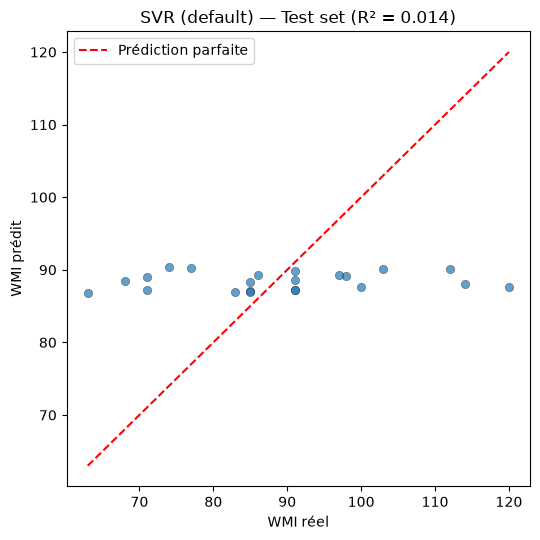

In [17]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_test, y_pred_test, alpha=0.7, edgecolor="k", linewidth=0.3)

lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, "r--", label="Prédiction parfaite")

ax.set_xlabel(f"{TARGET_COLUMN} réel")
ax.set_ylabel(f"{TARGET_COLUMN} prédit")
ax.set_title(f"{best_model_name} — Test set (R² = {test_r2:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

## Learning curve du modèle réellement retenu (sur le train)

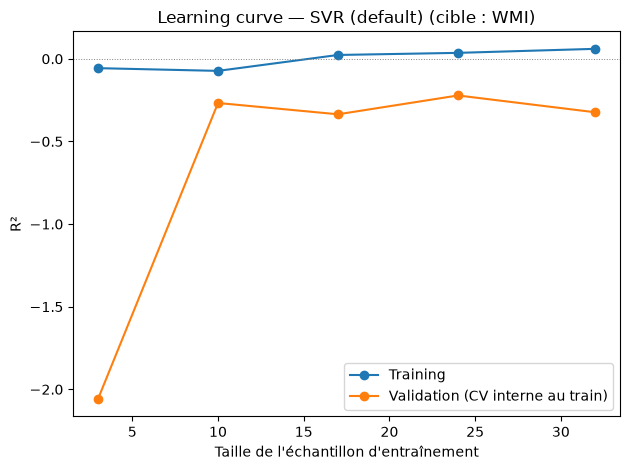

In [18]:
train_sizes, train_scores, val_scores = learning_curve(
    final_pipeline,
    X_train_imputed,
    np.ravel(y_train),
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 5),
)

plt.plot(train_sizes, np.mean(train_scores, axis=1), marker="o", label="Training")
plt.plot(train_sizes, np.mean(val_scores, axis=1), marker="o", label="Validation (CV interne au train)")
plt.axhline(0, color="grey", linewidth=0.7, linestyle=":")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("R²")
plt.title(f"Learning curve — {best_model_name} (cible : {TARGET_COLUMN})")
plt.legend()
plt.tight_layout()
plt.show()

## Résumé final

In [19]:
print(f"Cible prédite : {TARGET_COLUMN}")
print(f"Échantillon   : {X_train_imputed.shape[0]} (train) / {X_test_imputed.shape[0]} (test)")
print()
print("Classement des modèles (CV sur le train) :")
print(results_df.to_string(index=False))
print()
print("Performance du modèle retenu sur le test (jamais vu avant) :")
print(summary_test.to_string(index=False))

Cible prédite : WMI
Échantillon   : 41 (train) / 22 (test)

Classement des modèles (CV sur le train) :
            Model  R2_mean  R2_std  RMSE_mean  MAE_mean
    SVR (default)   -0.167   0.196     16.948    13.813
      SVR (tuned)   -0.168   0.198     16.952    13.801
    Random Forest   -0.504   0.469     18.803    15.370
      Elastic Net   -0.515   0.537     18.991    15.996
            Ridge   -0.543   0.570     19.134    16.175
            Lasso   -0.569   0.593     19.277    16.305
Linear Regression   -0.586   0.615     19.358    16.435
   PLS Regression   -0.614   0.642     19.482    16.269
Gradient Boosting   -0.812   0.966     20.029    16.185

Performance du modèle retenu sur le test (jamais vu avant) :
Modèle retenu  R² (test)  RMSE (test)  MAE (test)  R² CV (train)
SVR (default)      0.014         14.7      11.627         -0.167
